In [88]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model

# Lectura de CSV

In [89]:
# Ruta de la carpeta donde están los CSV
carpeta_csv = "./data/clean"

# Obtener todos los archivos CSV de la carpeta
archivos = [f for f in os.listdir(carpeta_csv)] #if f.endswith('.csv')]

# Lista para almacenar cada DataFrame
lista_df = []

In [90]:
len(archivos)

222

In [91]:
# Leer cada CSV y agregarlo a la lista
for archivo in archivos:
    ruta_archivo = os.path.join(carpeta_csv, archivo)
    df = pd.read_csv(ruta_archivo)
    lista_df.append(df)

# Unir todos los DataFrames en uno solo
df_final = pd.concat(lista_df, ignore_index=True)

# Mostrar las primeras filas del DataFrame final
print(df_final.sample(5))

          time  torque_spindle  velocity_spindle            source_file  \
663917   8.978         2.20459       77536.41406  Trace_0624_095025.csv   
74882    5.546         3.18896       75983.91406  Trace_0623_114448.csv   
567982   7.550         5.27051       75771.91406  Trace_0624_105635.csv   
141710   5.158         3.88623       77237.92969  Trace_0624_094629.csv   
1013569  7.544         3.82471       75457.62500  Trace_0623_104156.csv   

               path  Ae_mm  Ap_mm  f_mm_min        N_rpm  z  d_mm  
663917    C4240/V10     32    1.0     568.8  2148.591732  2    40  
74882     C1030/V07     26    1.2     632.4  2108.000000  2    40  
567982    C4240/V13     38    1.0     568.8  2108.000000  2    40  
141710   C4240/Plan     38    2.0     632.0  2108.000000  2    40  
1013569   C1030/V05     32    1.0     421.6  2108.000000  2    40  


In [92]:
df_final.dtypes

time                float64
torque_spindle      float64
velocity_spindle    float64
source_file          object
path                 object
Ae_mm                 int64
Ap_mm               float64
f_mm_min            float64
N_rpm               float64
z                     int64
d_mm                  int64
dtype: object

In [93]:
df = df_final.drop(columns = ['path'])

# Preparación de los datos

In [94]:
#División por archivos (80% train, 20% test)
# -----------------------------------------------------
#  - Separamos por source_file para evitar contaminación temporal/contextual.
#  - El split se hace antes de ajustar escaladores para evitar data leakage.
archivos = df['source_file'].unique()
n = len(archivos)
n_train = int(n * 0.8)

train_arch = archivos[:n_train]
test_arch  = archivos[n_train:]

# Crear dataframes por partición (contienen todas las filas de cada archivo)
df_train = df[df['source_file'].isin(train_arch)].copy()
df_test  = df[df['source_file'].isin(test_arch)].copy()

# Verificación rápida
print("Filas train:", len(df_train), " — filas test:", len(df_test))


Filas train: 1481167  — filas test: 367489


In [95]:
# =====================================================
# NORMALIZACIÓN MIXTA: por archivo y global
# =====================================================

# 1. Definir columnas
cols_dynamic = ['velocity_spindle']        # se normalizan POR ARCHIVO
target_col   = 'torque_spindle'            # se normaliza POR ARCHIVO

cols_static  = ['Ae_mm', 'Ap_mm', 'f_mm_min', 'N_rpm', 'z', 'd_mm']  # se normalizan GLOBALMENTE

columnas_features = cols_dynamic + cols_static #Unimos las columnas dinámicas y estáticas
# =====================================================
# 2. NORMALIZACIÓN GLOBAL de las columnas estáticas
#    (fit SOLO en TRAIN → evitar data leakage)
# =====================================================
from sklearn.preprocessing import MinMaxScaler

scaler_static = MinMaxScaler()
scaler_static.fit(df_train[cols_static])

df_train[cols_static] = scaler_static.transform(df_train[cols_static])
df_test[cols_static]  = scaler_static.transform(df_test[cols_static])

# =====================================================
# 3. NORMALIZACIÓN POR ARCHIVO de dinámicos y target
# =====================================================

def normalizar_por_archivo(df, cols_dyn, target):
    df_norm = df.copy()
    
    for file_id, group in df.groupby('source_file'):
        idx = group.index

        # Min–Max específico del archivo
        for col in cols_dyn + [target]:
            col_min = group[col].min()
            col_max = group[col].max()
            if col_max - col_min == 0:
                # si es constante → devolver 0
                df_norm.loc[idx, col] = 0.0
            else:
                df_norm.loc[idx, col] = (group[col] - col_min) / (col_max - col_min)

    return df_norm


df_train = normalizar_por_archivo(df_train, cols_dynamic, target_col)
df_test  = normalizar_por_archivo(df_test,  cols_dynamic, target_col)

print("Normalización mixta completada.")
print(df_train.describe())


Normalización mixta completada.
               time  torque_spindle  velocity_spindle         Ae_mm  \
count  1.481167e+06    1.481167e+06      1.481167e+06  1.481167e+06   
mean   8.639650e+00    4.770682e-01      5.065930e-01  6.975670e-01   
std    5.850688e+00    2.626478e-01      1.197403e-01  3.200377e-01   
min    0.000000e+00    0.000000e+00      0.000000e+00  0.000000e+00   
25%    4.120000e+00    2.286641e-01      4.512037e-01  4.285714e-01   
50%    8.234000e+00    4.954137e-01      5.088685e-01  8.571429e-01   
75%    1.247000e+01    6.963460e-01      5.686768e-01  8.571429e-01   
max    2.048380e+02    1.000000e+00      1.000000e+00  1.000000e+00   

              Ap_mm      f_mm_min         N_rpm          z       d_mm  
count  1.481167e+06  1.481167e+06  1.481167e+06  1481167.0  1481167.0  
mean   5.421214e-01  3.182264e-01  4.826251e-01        0.0        0.0  
std    4.158420e-01  1.439265e-01  1.521697e-01        0.0        0.0  
min    0.000000e+00  0.000000e+00  0.000

In [96]:
timesteps = 10

def crear_secuencias(df, timesteps, feature_cols, target_col='torque_spindle'):
    # Creamos secuencias para cada serie de tiempo
    X_list = []
    y_list = []
    
    # Iterar por cada serie de tiempo
    for id_serie, group in df.groupby('source_file'):
        group = group.sort_values('time')
        features = group[feature_cols].values
        target = group[target_col].values
        
        for i in range(len(group) - timesteps):
            X_list.append(features[i:i+timesteps])
            y_list.append(target[i+timesteps])
    
    return np.array(X_list), np.array(y_list)


# Crear secuencias para train y test
X_train, y_train = crear_secuencias(df_train, timesteps, columnas_features, target_col)
X_test,  y_test  = crear_secuencias(df_test,  timesteps, columnas_features, target_col)

print("Shape de X_train:", X_train.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_test:", y_test.shape)


Shape de X_train: (1479397, 10, 7)
Shape de y_train: (1479397,)
Shape de X_test: (367039, 10, 7)
Shape de y_test: (367039,)


# LTSM

In [100]:
#Construcción del modelo
model = Sequential([
    Input(shape=(timesteps, len(columnas_features))), # Capa de entrada con forma adecuada
    LSTM(50, activation="tanh"), # Tipo de capa LSTM con 50 unidades y activación tanh
    Dense(1) # Capa densa para la predicción de salida
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 50)             │        11,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,651 (45.51 KB)

 Trainable params: 11,651 (45.51 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
#Entrenamiento del modelo
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
)


Epoch 1/50
46232/46232 ━━━━━━━━━━━━━━━━━━━━ 92s 2ms/step - loss: 0.0616 - mae: 0.2075 - val_loss: 0.0707 - val_mae: 0.2231
Epoch 2/50
46232/46232 ━━━━━━━━━━━━━━━━━━━━ 92s 2ms/step - loss: 0.0604 - mae: 0.2051 - val_loss: 0.0638 - val_mae: 0.2118
Epoch 3/50
46232/46232 ━━━━━━━━━━━━━━━━━━━━ 92s 2ms/step - loss: 0.0590 - mae: 0.2021 - val_loss: 0.0641 - val_mae: 0.2133
Epoch 4/50
46232/46232 ━━━━━━━━━━━━━━━━━━━━ 92s 2ms/step - loss: 0.0586 - mae: 0.2012 - val_loss: 0.0637 - val_mae: 0.2117
Epoch 5/50
46232/46232 ━━━━━━━━━━━━━━━━━━━━ 122s 3ms/step - loss: 0.0584 - mae: 0.2009 - val_loss: 0.0636 - val_mae: 0.2113
Epoch 6/50
46232/46232 ━━━━━━━━━━━━━━━━━━━━ 92s 2ms/step - loss: 0.0583 - mae: 0.2007 - val_loss: 0.0637 - val_mae: 0.2128
Epoch 7/50
46232/46232 ━━━━━━━━━━━━━━━━━━━━ 91s 2ms/step - loss: 0.0583 - mae: 0.2006 - val_loss: 0.0636 - val_mae: 0.2113
Epoch 8/50
46232/46232 ━━━━━━━━━━━━━━━━━━━━ 90s 2ms/step - loss: 0.0580 - mae: 0.1999 - val_loss: 0.0638 - val_mae: 0.2114
Epoch 9/50
4623

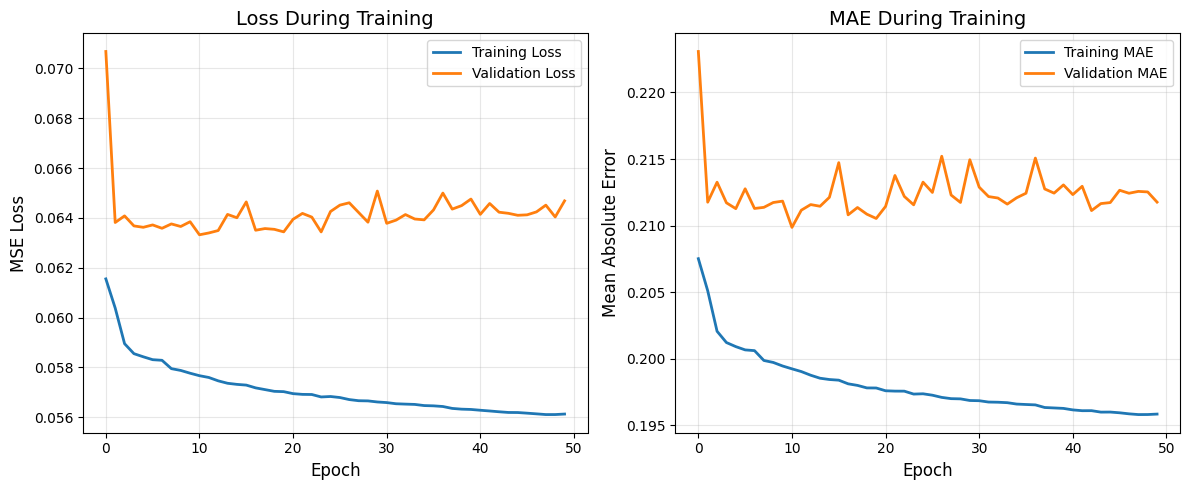

In [104]:
#Graficamos el historial de la perdida y del MAE en entrenamiento y validación
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
    # --- Loss ---
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title("Loss During Training", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Loss", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# --- MAE ---
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE', linewidth=2)
plt.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
plt.title("MAE During Training", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Mean Absolute Error", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [105]:
#Calculo del gap entre pérdida de entrenamiento y validación
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
loss_gap = final_val_loss - final_train_loss
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")   
print(f"Loss Gap: {loss_gap:.4f}")

Final Training Loss: 0.0561
Final Validation Loss: 0.0647
Loss Gap: 0.0086


In [ ]:
#Gap entre métrica de entrenamiento y validación
final_train_mae = history.history['mae'][-1]
final_val_mae = history.history['val_mae'][-1]
mae_gap = final_val_mae - final_train_mae
print(f"Final Training MAE: {final_train_mae:.4f}")
print(f"Final Validation MAE: {final_val_mae:.4f}")
print(f"MAE Gap: {mae_gap:.4f}")

Final Training MAE: 0.1958
Final Validation MAE: 0.2118
MAE Gap: 0.0159


In [107]:
#Guardamos modelo 
model.save("modelo_lstm.keras")
